# Notebook to make Figure 1: Summary of p-values for all PPCs

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

## Setup

Load data

In [2]:
pTdict = np.load('../data/pT_summary.npz', allow_pickle=True)['arr_0'].item()

Plotting labels, aesthetics, etc.

In [3]:
runs = ['_gaussian_sigma_0.1', '_gaussian_sigma_0.3', '_gaussian_sigma_0.5', '']
ppcs = ['eventlevel', 'datalevel', 'zp_partial', 'std_partial', 'split']
Ts = ['mean', 'standard deviation', 'zero to positive', 'costheta above 0.5']

T_labels = {
    'mean':r'$T=$ mean',
    'standard deviation':r'$T = $ standard deviation',
    'zero to positive': r'$T = \frac{N(\cos\theta \in [-0.33, 0.33])}{N(\cos\theta \in [0.33, 1])}$',
    'costheta above 0.5':r'$T=$ fraction $|\cos\theta\,|>0.5$'
}
run_labels = {
    '_gaussian_sigma_0.1':r'Gaussian $\mathcal{L}$, $\sigma_{\rm meas} = 0.1$',
    '_gaussian_sigma_0.3':r'Gaussian $\mathcal{L}$, $\sigma_{\rm meas} = 0.3$',
    '_gaussian_sigma_0.5':r'Gaussian $\mathcal{L}$, $\sigma_{\rm meas} = 0.5$',
    '':'Realistic O3 noise $\mathcal{L}$'
}
run_colors = {
    '_gaussian_sigma_0.1':'#FF5733', 
    '_gaussian_sigma_0.3':'#6A6BAD',
    '_gaussian_sigma_0.5':'#0099FF',
    '':'#A1C935',
}
scatter_kws = {
    'eventlevel':dict(marker='o',s=30),
    'datalevel':dict(marker='*',s=50),
    'zp_partial':dict(marker='1',s=50),
    'std_partial':dict(marker='4',s=50),
    'split':dict(marker='d',s=40),
}
ppc_labels = {
    'eventlevel':'Event level',
    'datalevel':'Data level',
    'zp_partial':'Partial ($N$)',
    'std_partial':'Partial ($\sigma$)',
    'split':'Split',
}

grid_kws = dict(color='silver', lw=0.5, alpha=0.7, ls=':', zorder=0)

## Make figure

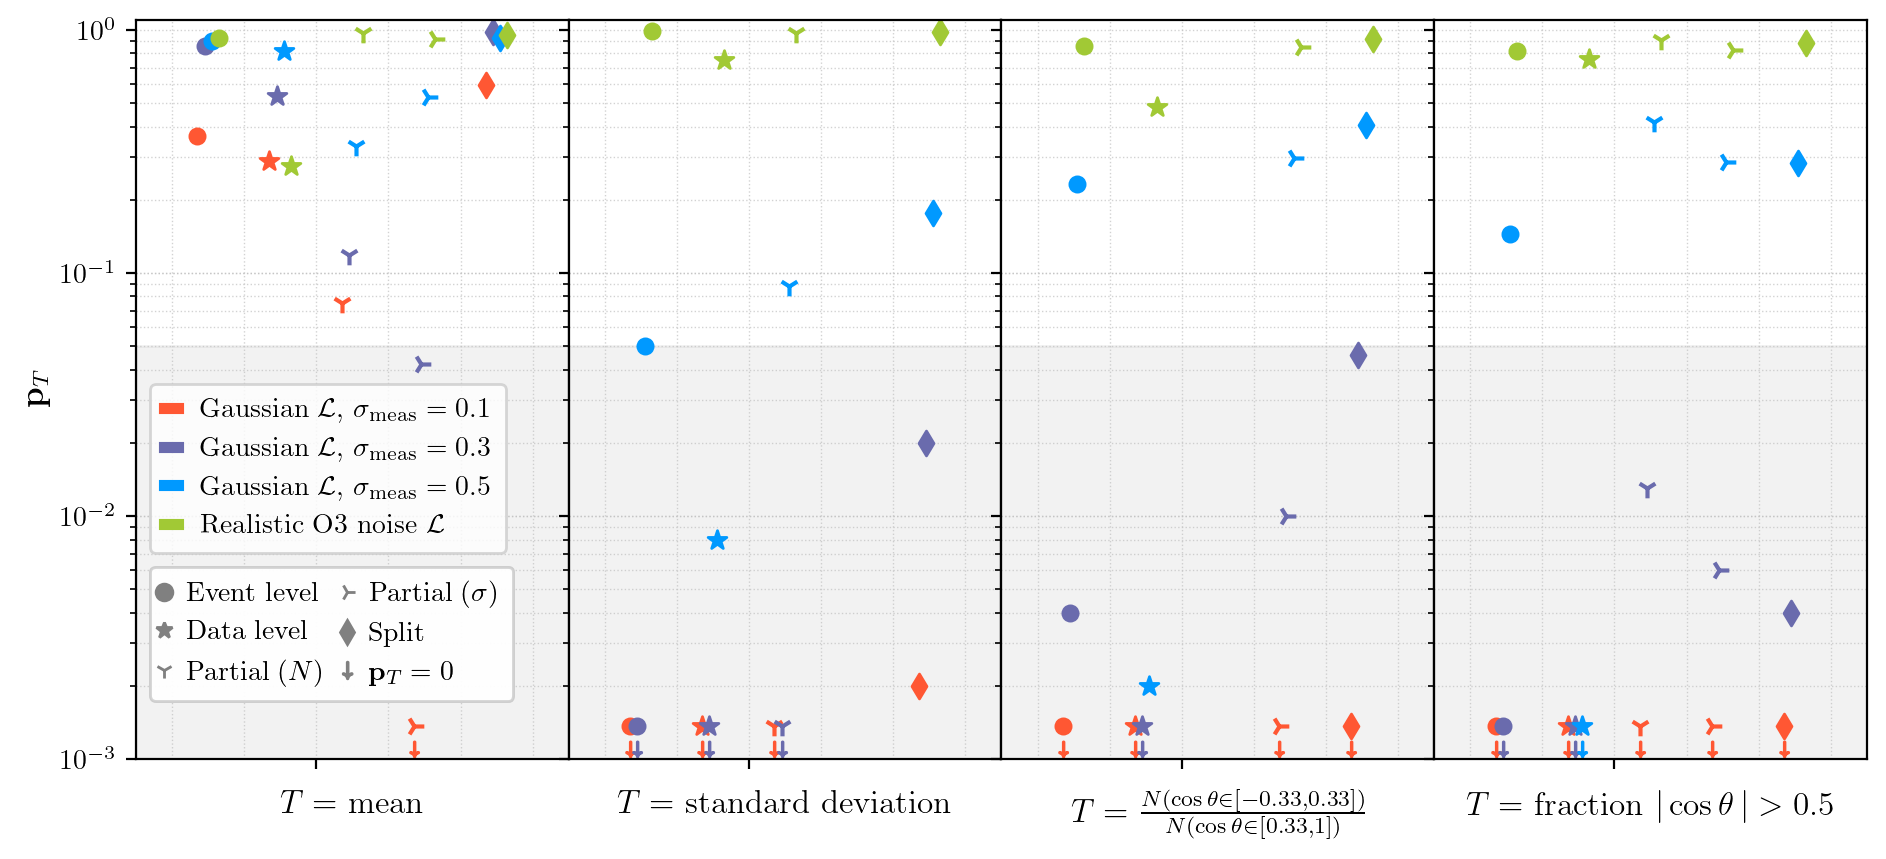

In [4]:
fig, axes = plt.subplots(1,4,figsize=(8*(4/3)+0.5,4.8), sharex=True, sharey=True)

min_p = 1e-3

# Cycle through test statistics (T) and corresponding ae
for ax,T in zip(axes,Ts):
    i = 0

    # Cycle through each PPC
    for ppc in ppcs:

        # Cycle through each single-event likelihood
        for j, run in enumerate(runs):

            # Fetch p-value for this case
            pval = pTdict[run][ppc][T]

            # Set x position
            x = i + j*0.1 - 0.15

            # Skip the partial PPCs if we are plotting the fixed test statistic (T = T_0)    
            if not ((ppc=='zp_partial' and T=='zero to positive') or (ppc=='std_partial' and T=='standard deviation')):
    
                if pval == 0:
                    ax.scatter([x], [min_p+0.00037], c=run_colors[run], **scatter_kws[ppc])
                    ax.scatter([x], [min_p+0.0001], c=run_colors[run], s=30, marker='$\downarrow$')
                else:
                    ax.scatter([x], [pval], c=run_colors[run], **scatter_kws[ppc])
        i+=1


    # Set up custom x and y grids
    for x in [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]:
        ax.axvline(x, **grid_kws)
    powers = [-3, -2, -1]
    mains = np.arange(1, 11, 1)
    loggrid = [m*10**p for m in mains for p in powers]
    for y in loggrid:
        ax.axhline(y, **grid_kws)

    # Fill in the region below p=0.05
    lims = [-1,i]
    ax.fill_between(lims,[0,0],[0.05,0.05], color='silver', alpha=0.2, zorder=0)
    ax.set_xlim(*lims)
    
    # Axes formatting
    ax.set_ylim(min_p,1.1)
    ax.set_yscale('log')
    ax.set_xticks([1.5])
    ax.set_xticklabels([])
    ax.set_xlabel(T_labels[T])

axes[0].set_ylabel(r'$\mathbf{p}_T$')

# Make two legends, one for colors (single-event likelihoods) and one for shapes (diffrent PPCs)
handles1 = [Line2D([], [], color=run_colors[run], lw=4, label=run_labels[run]) for run in runs]
handles2 = [
    *[Line2D([], [], color='gray', marker=scatter_kws[ppc]['marker'], label=ppc_labels[ppc]) for ppc in ppcs],
    Line2D([], [], color='gray', marker='$\downarrow$', label=r'$\mathbf{p}_T=0$')
]
dy = 0.06
lgd_kws = dict(borderpad=0.5, loc='lower left')
first_legend = axes[0].legend(handles=handles1, handlelength=0.5, bbox_to_anchor=(0, 0.2+dy), **lgd_kws) 
second_legend = axes[0].legend(handles=handles2, handlelength=0, ncol=2, columnspacing=0.8, bbox_to_anchor=(0, dy), **lgd_kws)
axes[0].add_artist(first_legend)
axes[0].add_artist(second_legend)

plt.subplots_adjust(wspace=0) 

# Save figure
plt.savefig('figure_01.png', dpi=400, bbox_inches='tight')
plt.show()